<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

In [209]:
from google.colab import drive

drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [210]:
!pip install accelerate -U

In [211]:
!pip install datasets

In [212]:
!pip install transformers

In [213]:
!pip install evaluate

In [214]:
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(palette='summer')
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import AutoModel, BertForSequenceClassification, AutoTokenizer, AutoConfig

In [258]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Создадим датасет

In [216]:
df = pd.read_excel('/content/gdrive/MyDrive/data_problems_translated.xlsx').drop(columns=['Unnamed: 0']).dropna()

df.head()

,problem_text,topic
0,To prove that the sum of the numbers of the ex...,number_theory
1,( b) Will the statement of the previous challe...,number_theory
2,The quadratic three-member graph with the coef...,polynoms
3,Can you draw on the surface of Rubik's cube a ...,combinatorics
4,"Dima, who came from Vrunlandia, said that ther...",graphs


In [217]:
X = df['problem_text']
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['topic'])

num_classes = df['topic'].nunique()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

train_dataset = Dataset.from_pandas(pd.DataFrame({'text': X_train, 'label': y_train})).remove_columns("__index_level_0__")
test_dataset = Dataset.from_pandas(pd.DataFrame({'text': X_test, 'label': y_test})).remove_columns("__index_level_0__")
dataset = Dataset.from_pandas(pd.DataFrame({'text': X, 'label': y}))

In [218]:
train_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 4214
})

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [219]:

class TransformerClassificationModel(nn.Module):
    def __init__(self, model_name: str, num_classes: int):
        super(TransformerClassificationModel, self).__init__()

        if isinstance(model_name, str):
            self.config = AutoConfig.from_pretrained(model_name)
            self.backbone = AutoModel.from_pretrained(model_name)
        else:
            self.config = model_name.config
            self.backbone = model_name

        hidden_size = self.backbone.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size // 2, num_classes)
        )
        self.loss_fn = nn.CrossEntropyLoss()


    def forward(self, input_ids, attention_mask=None, token_type_ids=None, labels=None):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_output)

        logits = logits.contiguous()

        loss = None
        if labels is not None:
            loss = self.loss_fn(logits, labels)

        return {"loss": loss, "logits": logits}

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [220]:
def freeze_backbone_function(model: TransformerClassificationModel):
    for param in model.backbone.parameters():
        param.requires_grad = False
        param.data = param.data.contiguous()
    return model

Загрузим токенизатор

In [221]:
tokenizer = AutoTokenizer.from_pretrained('cointegrated/rubert-tiny2')

In [222]:
def preprocess_function(examples):
    return tokenizer(examples["text"], padding="max_length",
                     truncation=True, max_length=128)

In [223]:
train_dataset = train_dataset.map(preprocess_function, batched=True)
test_dataset = test_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/4214 [00:00<?, ? examples/s]

Map:   0%|          | 0/1054 [00:00<?, ? examples/s]

In [224]:
test_dataset

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1054
})

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [225]:
from transformers import Trainer,TrainingArguments

In [226]:
import copy

def train_transformer(transformer_model, freeze_backbone=True):

    model = copy.copy(transformer_model)

    if freeze_backbone:
        freeze_backbone_function(model)

    for param in model.parameters():
        param.data = param.data.contiguous()

    trainer.train()

    return model

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [227]:
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to='none'

)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [228]:
from sklearn.metrics import accuracy_score

In [229]:
def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    return {"accuracy": accuracy_score(eval_pred.label_ids, preds)}

In [230]:
rubert_tiny_transformer_model = TransformerClassificationModel(model_name="cointegrated/rubert-tiny2",
                                       num_classes=len(label_encoder.classes_))

In [231]:
trainer = Trainer(
model=rubert_tiny_transformer_model,
args=training_args,
train_dataset=train_dataset,
eval_dataset=test_dataset,
compute_metrics=compute_metrics)

In [232]:
rubert_tiny_finetuned_with_freezed_backbone = train_transformer(rubert_tiny_transformer_model, freeze_backbone=True)

Epoch,Training Loss,Validation Loss,Accuracy
1,1.308300,1.143888,0.570209
2,1.108200,1.074953,0.587287
3,1.052400,1.046028,0.588235
4,1.020200,1.031767,0.585389
5,0.997800,1.016773,0.594877
6,0.982100,1.023053,0.599620
7,0.969000,1.008986,0.596774
8,0.959200,1.009637,0.591082
9,0.951700,1.007093,0.594877
10,0.941200,1.006110,0.593928


In [233]:
rubert_tiny_transformer_model = TransformerClassificationModel(model_name="cointegrated/rubert-tiny2",
                                       num_classes=len(label_encoder.classes_))

In [234]:
trainer = Trainer(
model=rubert_tiny_transformer_model,
args=training_args,
train_dataset=train_dataset,
eval_dataset=test_dataset,
compute_metrics=compute_metrics)

In [235]:
rubert_tiny_full_finetuned = train_transformer(rubert_tiny_transformer_model, freeze_backbone=False)

Epoch,Training Loss,Validation Loss,Accuracy
1,1.193100,1.129426,0.577799
2,0.926300,1.072348,0.596774
3,0.754800,1.125015,0.578748
4,0.609400,1.279503,0.565465
5,0.531400,1.299255,0.573055
6,0.457900,1.596728,0.543643
7,0.401900,1.731387,0.534156
8,0.358200,1.938442,0.518975
9,0.315500,2.016836,0.519924
10,0.285700,2.178684,0.520873


### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [236]:
tokenizer = AutoTokenizer.from_pretrained("tbs17/MathBERT")

In [237]:
train_dataset = Dataset.from_pandas(pd.DataFrame({'text': X_train, 'label': y_train})).remove_columns("__index_level_0__")
test_dataset = Dataset.from_pandas(pd.DataFrame({'text': X_test, 'label': y_test})).remove_columns("__index_level_0__")

train_dataset = train_dataset.map(preprocess_function, batched=True)
test_dataset = test_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/4214 [00:00<?, ? examples/s]

Map:   0%|          | 0/1054 [00:00<?, ? examples/s]

In [238]:
mathbert_finetuned_with_freezed_backbone = TransformerClassificationModel(model_name="tbs17/MathBERT",
                                       num_classes=len(label_encoder.classes_))

In [239]:
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    report_to='none',
    remove_unused_columns=False

)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [240]:
trainer = Trainer(
    model=mathbert_finetuned_with_freezed_backbone,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,

)

In [241]:
MathBERT_Freeze = train_transformer(mathbert_finetuned_with_freezed_backbone, freeze_backbone=True)

Epoch,Training Loss,Validation Loss,Accuracy
1,1.418500,1.259565,0.525617
2,1.194200,1.178932,0.545541
3,1.126500,1.133910,0.550285
4,1.088100,1.125055,0.553131
5,1.080700,1.108299,0.558824
6,1.055800,1.111383,0.557875
7,1.044600,1.100514,0.555977
8,1.035500,1.097139,0.554080
9,1.023900,1.098064,0.555028
10,1.014900,1.097896,0.556926


In [242]:
MathBERT_full_finetuned = train_transformer(mathbert_finetuned_with_freezed_backbone, freeze_backbone=False)

Epoch,Training Loss,Validation Loss,Accuracy
1,1.056900,1.137018,0.553131
2,1.042100,1.107849,0.553131
3,1.020500,1.100702,0.566414
4,1.008800,1.110098,0.552182
5,0.998400,1.102538,0.562619
6,0.983600,1.108918,0.556926
7,0.976300,1.092450,0.565465
8,0.976800,1.094314,0.558824
9,0.969200,1.095471,0.562619
10,0.962500,1.096989,0.560721


### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [247]:
from typing import Union, Dict, List
def draw_first_layer_attention_maps(attention_head_ids: List[int], text: str,
    model, model_name: str, figsize: tuple = (6, 12)):

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    input_ids = inputs["input_ids"]

    with torch.no_grad():
        outputs = model.backbone(**inputs, output_attentions=True)


    attentions = outputs.attentions[0][0]

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    fig, axes = plt.subplots(ncols=len(attention_head_ids), figsize=figsize)
    if len(attention_head_ids) == 1:
        axes = [axes]

    for i, head_id in enumerate(attention_head_ids):
        ax = axes[i]
        attention_weights = attentions[head_id].numpy()

        valid_indices = [i for i, token in enumerate(tokens) if token not in ["[CLS]", "[SEP]", "[PAD]"]]
        filtered_weights = attention_weights[np.ix_(valid_indices, valid_indices)]
        filtered_tokens = [tokens[i] for i in valid_indices]

        im = ax.imshow(filtered_weights, cmap='viridis')

        ax.set_xticks(range(len(filtered_tokens)))
        ax.set_yticks(range(len(filtered_tokens)))
        ax.set_xticklabels(filtered_tokens, rotation=90)
        ax.set_yticklabels(filtered_tokens)
        ax.grid(False)
        ax.set_title(f"Head # {head_id}")

    plt.tight_layout()
    plt.show()

### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

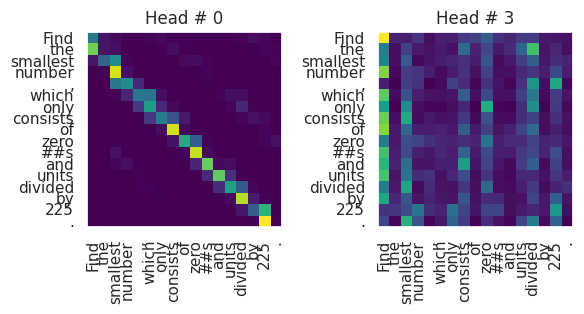

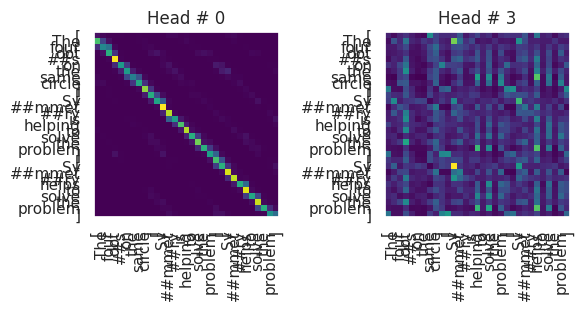

In [256]:
text1 = test_dataset['text'][1]
text2 = test_dataset['text'][4]
model = TransformerClassificationModel("cointegrated/rubert-tiny2", num_classes=7)

draw_first_layer_attention_maps([0, 3], text1, model, "cointegrated/rubert-tiny2")
draw_first_layer_attention_maps([0, 3], text2, model, "cointegrated/rubert-tiny2")

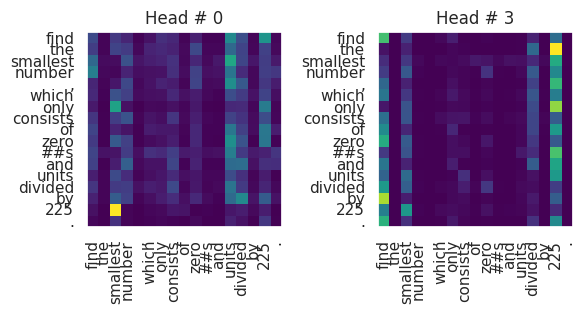

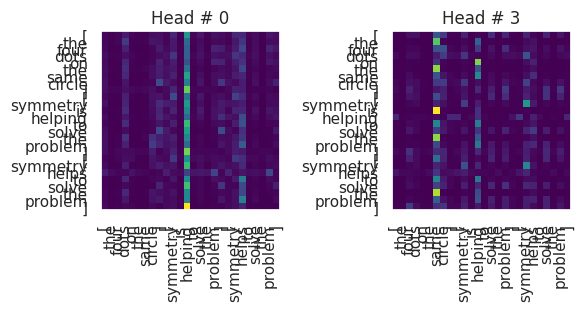

In [255]:
text1 = test_dataset['text'][1]
text2 = test_dataset['text'][4]
model = TransformerClassificationModel("tbs17/MathBert", num_classes=7)

draw_first_layer_attention_maps([0, 3], text1, model, "tbs17/MathBert")
draw_first_layer_attention_maps([0, 3], text2, model, "tbs17/MathBert")

Обе модели по-разному строят карты внимания. Также сами головы у одной модели отличаются

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

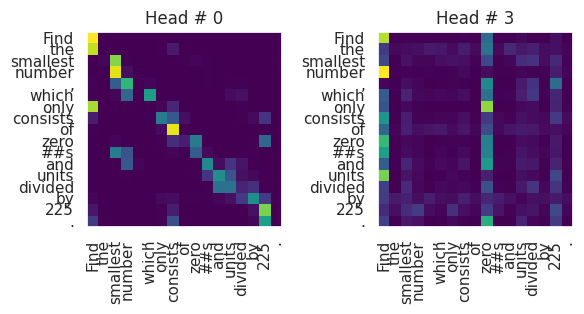

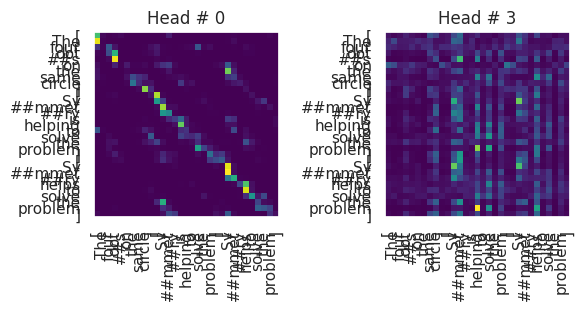

In [259]:
text1 = test_dataset['text'][1]
text2 = test_dataset['text'][4]
model = rubert_tiny_transformer_model
model = model.to('cpu')

draw_first_layer_attention_maps([0, 3], text1, model, "cointegrated/rubert-tiny2")
draw_first_layer_attention_maps([0, 3], text2, model, "cointegrated/rubert-tiny2")

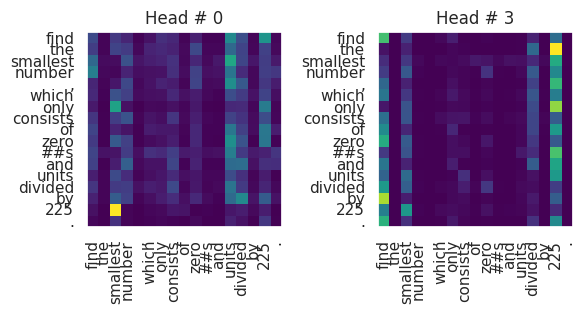

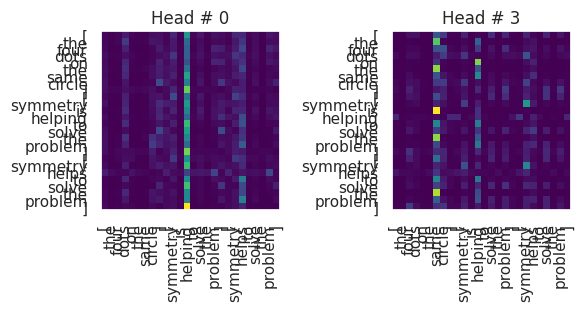

In [260]:
text1 = test_dataset['text'][1]
text2 = test_dataset['text'][4]
model = mathbert_finetuned_with_freezed_backbone
model = model.to('cpu')

draw_first_layer_attention_maps([0, 3], text1, model, "tbs17/MathBert")
draw_first_layer_attention_maps([0, 3], text2, model, "tbs17/MathBert")

#### Карты внимания не сильно изменились. Возможно, модели не удается на таком небольшом датасете начать выявлять более крутые закономерности